In [1]:
#!pip install git+https://github.com/GiadaLalli/ISN-tractor

In [4]:
!python --version

Python 3.10.14


In [5]:
import gc
gc.collect()

1655

In [6]:
in_colab = False

In [7]:
if in_colab:

  from google.colab import drive
  drive.mount("/content/drive/", force_remount = True)

In [8]:
if in_colab:
  !pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 #-f https://download.pytorch.org/whl/cu121

In [9]:
if in_colab:
  !pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.3.0+cpu.html#torch-2.3.0+cu121.html

In [10]:
if in_colab:
  !pip install torch_geometric

In [11]:
if in_colab:
  import locale
  def getpreferredencoding(do_setlocale = True):
      return "UTF-8"
  locale.getpreferredencoding = getpreferredencoding
  !pip install pygod

In [12]:
import torch
torch.__version__

'2.4.0+cu121'

In [13]:
import torch_geometric
print(torch_geometric.typing.WITH_PYG_LIB)

True


In [14]:
if in_colab:
  %cd "/content/drive/MyDrive/Colab Notebooks/GraphOutlierDetection"

In [15]:
!dir

 Il volume nell'unit… C Š Windows
 Numero di serie del volume: 123E-4DB7

 Directory di C:\Users\ugo-c\Desktop\ADIN

21/10/2024  15:21    <DIR>          .
15/10/2024  14:04    <DIR>          ..
21/10/2024  14:58    <DIR>          .ipynb_checkpoints
21/10/2024  14:58    <DIR>          .virtual_documents
21/10/2024  14:57    <DIR>          adin
17/10/2024  16:14    <DIR>          assets
16/10/2024  15:20        10.037.628 gaan.pt
18/10/2024  20:15         5.063.500 god.ipynb
21/10/2024  15:21           394.993 god_isn.ipynb
26/09/2024  15:50             1.088 LICENSE
18/10/2024  17:03            77.273 main.py
24/09/2024  21:03         1.636.551 ML_GEO.ipynb
30/09/2024  10:59             1.197 README.md
30/09/2024  10:47               297 requirements.txt
30/09/2024  10:47               297 requirementscuda.txt
30/09/2024  10:47               152 requirementstorch.txt
30/09/2024  10:47               145 requirementstorchcuda.txt
17/09/2024  10:15    <DIR>          use_case
              

In [16]:
import os
cwd = os.getcwd()
sep = os.sep
datapath = cwd + sep + "Dataset" + sep
datapath

'C:\\Users\\ugo-c\\Desktop\\ADIN\\Dataset\\'

In [17]:
expr_filename = cwd + sep + "use_case"+sep+"data"+sep+"bladder_cancer"+sep+"gene_expression_data_preprocessed.csv"
output = cwd + sep + "ouput.png"

In [18]:
import pandas as pd

expr = pd.read_csv(expr_filename, index_col = 0)
expr

,ATP2A1,SLMAP,MEOX2,HOXD3,ZNF398,PANX1,COX8C,IMPA2,TTC8,FLJ35816,...,ZFP2.1,CST9L.1,C11orf24.1,QPRT.1,LEPRE1.1,GNAS.29,RPN1.1,CYB5A.1,AP1S1.1,Target
GSM928410,0.663336,0.529598,0.162563,0.383908,0.096852,0.137029,0.971139,0.039016,0.029115,0.530092,...,0.174781,0.759511,0.103661,0.200964,0.200289,0.397994,0.031667,0.116547,0.061299,0
GSM928411,0.732851,0.637804,0.087245,0.364565,0.100989,0.104867,0.968545,0.046063,0.035143,0.592064,...,0.094503,0.747333,0.085542,0.224168,0.103062,0.376746,0.028174,0.069490,0.101310,0
GSM928412,0.731909,0.467229,0.151392,0.410514,0.105380,0.118404,0.961028,0.043965,0.031300,0.554694,...,0.110763,0.764336,0.102852,0.236077,0.155706,0.383049,0.019629,0.077901,0.089061,0
GSM928413,0.756482,0.712974,0.125020,0.438931,0.072189,0.117990,0.971448,0.044214,0.031502,0.587456,...,0.052426,0.775798,0.109610,0.217205,0.176550,0.412991,0.034196,0.062415,0.061597,0
GSM928414,0.627336,0.374188,0.072009,0.564686,0.083819,0.094375,0.968190,0.028884,0.018645,0.596519,...,0.043576,0.792672,0.094405,0.219325,0.125886,0.396564,0.021866,0.046562,0.043234,0
GSM928415,0.668793,0.394460,0.122008,0.392940,0.084649,0.105771,0.973028,0.041213,0.023148,0.579087,...,0.113668,0.757963,0.079168,0.245785,0.117861,0.300823,0.027338,0.049083,0.084346,0
GSM928416,0.426092,0.256789,0.158605,0.744571,0.093180,0.117594,0.971882,0.050376,0.049978,0.508073,...,0.052173,0.777005,0.084534,0.231139,0.226753,0.396463,0.028637,0.082773,0.045241,1
GSM928417,0.543068,0.161934,0.095487,0.781442,0.045247,0.119621,0.964217,0.040574,0.030213,0.378127,...,0.051021,0.745892,0.098363,0.204016,0.191636,0.173303,0.014033,0.053147,0.035183,1
GSM928418,0.806099,0.783551,0.182352,0.764526,0.086602,0.122421,0.963932,0.043778,0.030160,0.501038,...,0.060801,0.801456,0.091301,0.217928,0.198903,0.358943,0.028659,0.058941,0.042113,1
GSM928419,0.535368,0.125626,0.101444,0.811086,0.027037,0.069629,0.970158,0.032499,0.022672,0.557364,...,0.042587,0.790621,0.065476,0.230631,0.131507,0.407219,0.016708,0.056320,0.027419,1


In [19]:
clinic = pd.DataFrame(expr["Target"])
clinic

,Target
GSM928410,0
GSM928411,0
GSM928412,0
GSM928413,0
GSM928414,0
GSM928415,0
GSM928416,1
GSM928417,1
GSM928418,1
GSM928419,1


In [20]:
expr = expr.drop("Target", axis = 1)
expr

,ATP2A1,SLMAP,MEOX2,HOXD3,ZNF398,PANX1,COX8C,IMPA2,TTC8,FLJ35816,...,A2ML1.1,ZFP2.1,CST9L.1,C11orf24.1,QPRT.1,LEPRE1.1,GNAS.29,RPN1.1,CYB5A.1,AP1S1.1
GSM928410,0.663336,0.529598,0.162563,0.383908,0.096852,0.137029,0.971139,0.039016,0.029115,0.530092,...,0.626678,0.174781,0.759511,0.103661,0.200964,0.200289,0.397994,0.031667,0.116547,0.061299
GSM928411,0.732851,0.637804,0.087245,0.364565,0.100989,0.104867,0.968545,0.046063,0.035143,0.592064,...,0.671998,0.094503,0.747333,0.085542,0.224168,0.103062,0.376746,0.028174,0.069490,0.101310
GSM928412,0.731909,0.467229,0.151392,0.410514,0.105380,0.118404,0.961028,0.043965,0.031300,0.554694,...,0.602572,0.110763,0.764336,0.102852,0.236077,0.155706,0.383049,0.019629,0.077901,0.089061
GSM928413,0.756482,0.712974,0.125020,0.438931,0.072189,0.117990,0.971448,0.044214,0.031502,0.587456,...,0.627324,0.052426,0.775798,0.109610,0.217205,0.176550,0.412991,0.034196,0.062415,0.061597
GSM928414,0.627336,0.374188,0.072009,0.564686,0.083819,0.094375,0.968190,0.028884,0.018645,0.596519,...,0.710886,0.043576,0.792672,0.094405,0.219325,0.125886,0.396564,0.021866,0.046562,0.043234
GSM928415,0.668793,0.394460,0.122008,0.392940,0.084649,0.105771,0.973028,0.041213,0.023148,0.579087,...,0.658017,0.113668,0.757963,0.079168,0.245785,0.117861,0.300823,0.027338,0.049083,0.084346
GSM928416,0.426092,0.256789,0.158605,0.744571,0.093180,0.117594,0.971882,0.050376,0.049978,0.508073,...,0.221204,0.052173,0.777005,0.084534,0.231139,0.226753,0.396463,0.028637,0.082773,0.045241
GSM928417,0.543068,0.161934,0.095487,0.781442,0.045247,0.119621,0.964217,0.040574,0.030213,0.378127,...,0.268238,0.051021,0.745892,0.098363,0.204016,0.191636,0.173303,0.014033,0.053147,0.035183
GSM928418,0.806099,0.783551,0.182352,0.764526,0.086602,0.122421,0.963932,0.043778,0.030160,0.501038,...,0.265713,0.060801,0.801456,0.091301,0.217928,0.198903,0.358943,0.028659,0.058941,0.042113
GSM928419,0.535368,0.125626,0.101444,0.811086,0.027037,0.069629,0.970158,0.032499,0.022672,0.557364,...,0.141304,0.042587,0.790621,0.065476,0.230631,0.131507,0.407219,0.016708,0.056320,0.027419


In [21]:
import torch
device = "cuda:0" if torch.cuda.is_available() else "cpu"
device

'cuda:0'

In [22]:
import torch
import numpy as np

def parse_edges(edge_list):
    source_nodes = []
    target_nodes = []
    node_mapping = {}
    next_index = 0

    for edge in edge_list:
        source, target = edge.split('_')
        #if source == target:
        #    continue
        if source not in node_mapping:
            node_mapping[source] = next_index
            next_index += 1
        if target not in node_mapping:
            node_mapping[target] = next_index
            next_index += 1

        source_nodes.append(node_mapping[source])
        target_nodes.append(node_mapping[target])

    return source_nodes, target_nodes, node_mapping

def create_edge_index(source_nodes, target_nodes):
    edge_list = np.array([source_nodes, target_nodes], dtype=np.int64)
    edge_index = torch.LongTensor(edge_list)
    return edge_index

In [23]:
#!pip install numpy==1.24.1

In [24]:
from isn_tractor import ibisn as it
import numpy as np

In [25]:
import gc 
import isn_tractor as isn

def create_denseisns(expr):
    gc.collect()
    torch.cuda.empty_cache()
    isn_generator = it.dense_isn(expr, device)
    
    isns = []
    for i, isn in enumerate(isn_generator):
        print(i)
        isns.append(isn)
        del isn
        gc.collect()
        torch.cuda.empty_cache()
        break
    return isns

In [26]:
def create_interaction_df(expr):
    
    genes = expr.columns
    values = expr.values.T
    values = torch.from_numpy(values).to(device)

    print(values.shape)
    corr = torch.corrcoef(values)

    print(corr.shape)
    df = pd.DataFrame([], columns = ["feature_1", "feature_2"])
    idx = 0
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            if i != j:
                gene1 = genes[i]
                gene2 = genes[j]
                df.loc[idx] = [gene1, gene2]
                idx += 1 
    return df

In [27]:
expr.shape

(24, 27551)

In [28]:
interaction_df = create_interaction_df(expr[:50])
interaction_df

torch.Size([27551, 24])


OutOfMemoryError: CUDA out of memory. Tried to allocate 5.66 GiB. GPU 0 has a total capacity of 8.00 GiB of which 0 bytes is free. Of the allocated memory 11.33 GiB is allocated by PyTorch, and 8.62 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [26]:
def create_sparse_isns(expr): 
    
    interaction_df = create_interaction_df(expr[:50])
    isn_generator = it.sparse_isn(expr, None, interaction_df, "pearson", "average", device)
    
    isns = []
    for i, isn in enumerate(isn_generator):
        #print(i)
        isns.append(isn)
        del isn
        gc.collect()
        torch.cuda.empty_cache()

    return isns

In [27]:
isns = create_sparse_isns(expr)
isns[0].shape

torch.Size([24, 27551])
torch.Size([24, 24])


torch.Size([24])

In [28]:
isns = torch.stack(isns).to(device)
isns = isns.T
isns

tensor([[ 0.5765, -0.0369, -0.4678,  ...,  0.7421,  0.3082, -0.3739],
        [ 0.9085, -0.3653, -1.2591,  ...,  0.6512,  0.5532, -0.2262],
        [ 0.8104,  0.0802, -1.1500,  ...,  1.1488,  2.5935, -0.3293],
        ...,
        [ 0.8198,  1.1399, -0.4012,  ...,  0.8118,  0.5130,  0.5028],
        [ 1.1764, -3.0579, -0.6417,  ...,  0.7445,  0.7010, -0.5612],
        [ 0.7985,  2.8247, -1.5362,  ...,  0.2223, -0.0271,  0.0952]],
       device='cuda:0', dtype=torch.float64)

In [29]:
isns.shape

torch.Size([24, 552])

In [121]:
uqs, counts = torch.unique(dataloader_train.y, return_counts = True)
dict_counts = {}
for uq, count in zip(uqs, counts):
    dict_counts[uq.item()] = count.item()
contamination = (dict_counts[1]/(dict_counts[0] + dict_counts[1]))*0.5
contamination

0.375

In [122]:
from adin import utils, dl, gaan_config

In [174]:
gaan_params = gaan_config.GAAN_config(noise_dim=2,
    hid_dim=8,
    num_layers=4,
    dropout=0.3,
    contamination=contamination,
    lr=0.005,
    epoch=400,
    gpu=0,
    batch_size=128,
    verbose=1
)

In [175]:
from sklearn.metrics import confusion_matrix

models = {} 
edges = interaction_df.values
edges = [f"{edge[0]}_{edge[1]}" for edge in edges]
# Parse the edges and create node mapping
source_nodes, target_nodes, node_mapping = utils.parse_edges(edges)
# Create edge_index tensor
edge_index = utils.create_edge_index(source_nodes, target_nodes)
x = expr.values
y = clinic.values
mydataloader = dl.create_torch_geo_data(x, y, edge_index)
node_mapping_rev = {value: key for key, value in node_mapping.items()}
dataloader_train, dataloader_test = dl.train_test_split_and_mask(mydataloader, node_mapping_rev, train_size = 0.6)
in_dim = dataloader_train.x.shape[1]
model = dl.create_model(in_dim, gaan_params)
model = dl.train_gaan(model, dataloader_train)
models["GAAN"] = model

if "Temp" in models.keys():
    del models["Temp"]

GPU: 0
Epoch 0000: Loss I 3.8152 | Loss O 1.0127 | 
Epoch 0001: Loss I 3.8058 | Loss O 0.9450 | 
Epoch 0002: Loss I 3.0263 | Loss O 0.9950 | 
Epoch 0003: Loss I 2.1423 | Loss O 1.2426 | 
Epoch 0004: Loss I 3.0677 | Loss O 1.2762 | 
Epoch 0005: Loss I 2.6707 | Loss O 1.3417 | 
Epoch 0006: Loss I 2.5696 | Loss O 1.0338 | 
Epoch 0007: Loss I 2.3517 | Loss O 1.0846 | 
Epoch 0008: Loss I 1.4973 | Loss O 1.2075 | 
Epoch 0009: Loss I 1.1091 | Loss O 1.5291 | 
Epoch 0010: Loss I 1.8942 | Loss O 1.1558 | 
Epoch 0011: Loss I 1.0538 | Loss O 2.0211 | 
Epoch 0012: Loss I 1.0740 | Loss O 1.7320 | 
Epoch 0013: Loss I 1.3086 | Loss O 1.6118 | 
Epoch 0014: Loss I 1.2812 | Loss O 1.3545 | 
Epoch 0015: Loss I 0.8929 | Loss O 1.8429 | 
Epoch 0016: Loss I 0.6668 | Loss O 2.3415 | 
Epoch 0017: Loss I 1.0054 | Loss O 1.9362 | 
Epoch 0018: Loss I 0.4920 | Loss O 2.0397 | 
Epoch 0019: Loss I 0.6313 | Loss O 2.7123 | 
Epoch 0020: Loss I 1.3260 | Loss O 1.6527 | 
Epoch 0021: Loss I 0.4147 | Loss O 2.7851 | 
Epo

In [183]:
df_result = dl.create_results_df(model, dataloader_test)
df_result

Test: Loss I 0.0735 | Loss O 589.6331 | 


,Model name,ROC AUC,F1,Average Precision,Recall@k,Precision@k
0,GAAN,0.625,0.4,0.85,0.75,0.75


In [198]:
from adin import ml 
from torch_geometric.explain import GNNExplainer, Explainer
preds = model.predict(dataloader_train).cpu()
y_test = dataloader_train.y.cpu()
classes = {0: "Normal", 1: "Anomalous"}
cm = confusion_matrix(y_test, preds)
fig_cm = dl.plot_cm(classes, cm)
fig_roc_test = ml.plot_roc_curve_(y_test, preds)

Test: Loss I 0.0528 | Loss O 457.1429 | 


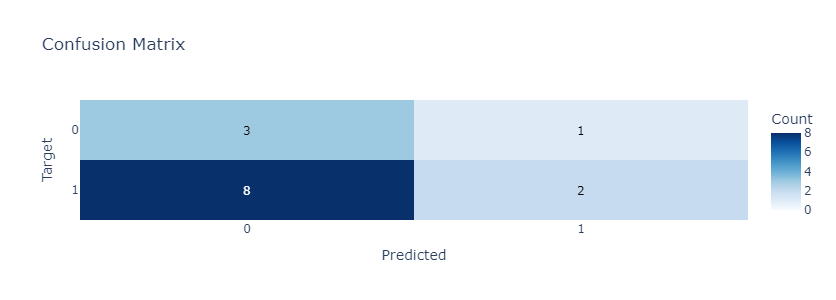

In [199]:
fig_cm.show()

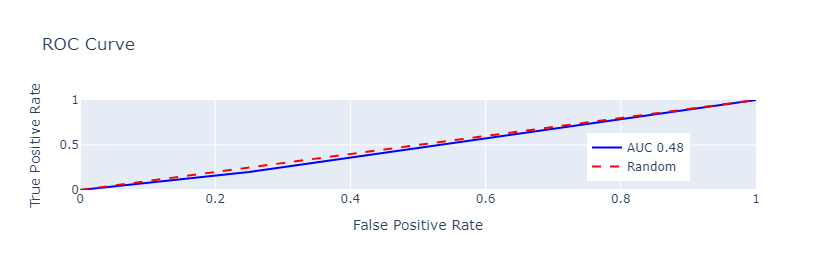

In [200]:
fig_roc_test.show()

In [201]:
explainer_graph = Explainer(
            model=model,
            algorithm=GNNExplainer(epochs=0),
            explanation_type='model',
            node_mask_type='attributes',
            edge_mask_type='object',
            model_config=dict(
                mode='binary_classification',
                task_level='graph',
                return_type='probs',
            ),
)

Test: Loss I 0.0739 | Loss O 640.0000 | 


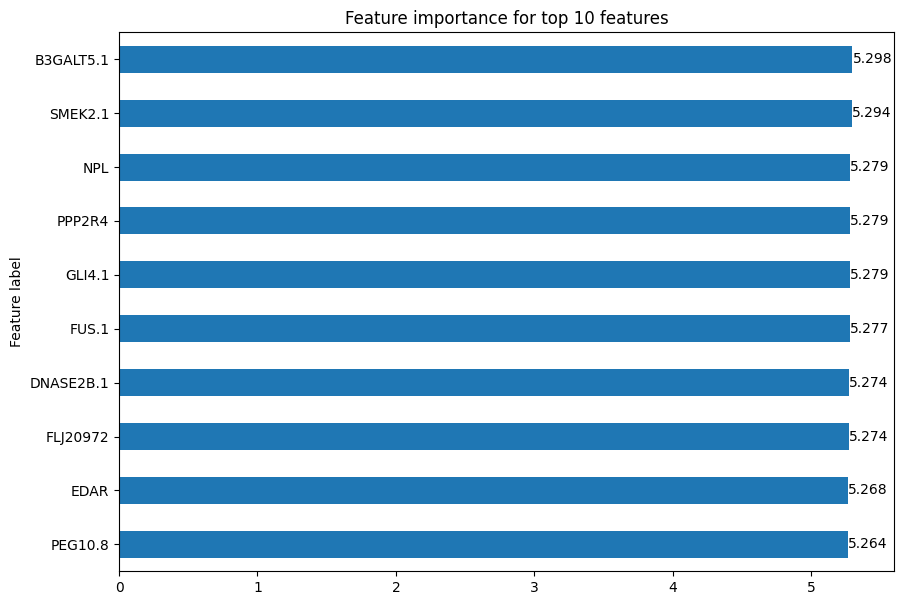

In [202]:
genes = expr.columns
explanation = explainer_graph(dataloader_test.x, dataloader_test.edge_index, index=10)
explanation.visualize_feature_importance(top_k=10, feat_labels = genes)

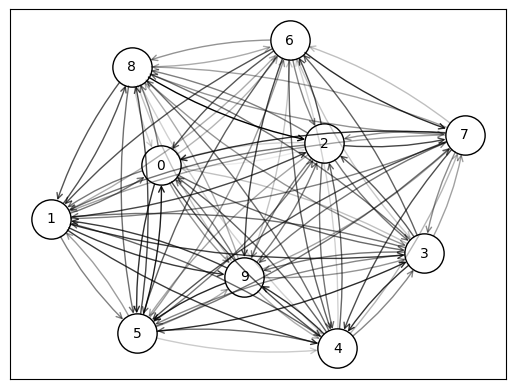

In [203]:
explanation.visualize_graph()

In [204]:
from torch_geometric.explain import unfaithfulness

metric = unfaithfulness(explainer_graph, explanation)
print(metric)

Test: Loss I 0.0739 | Loss O 640.0000 | 


IndexError: index 10 is out of bounds for dimension 0 with size 10